In [ ]:
# Télécharger le dataset directement depuis une URL
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data -O iris.csv

# Importer TOUTES les librairies dont on aura besoin
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn pour le prétraitement et les modèles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

--2026-05-05 21:32:26--  https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘iris.csv’

iris.csv                [ <=>                ]   4.44K  --.-KB/s    in 0s      

2026-05-05 21:32:26 (58.8 MB/s) - ‘iris.csv’ saved [4551]



In [3]:
# Donner des noms aux colonnes pour s'y retrouver
col_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
df = pd.read_csv('iris.csv', names=col_names)

print("✅ Dataset chargé ! Voici les 5 premières lignes :")
df.head()

✅ Dataset chargé ! Voici les 5 premières lignes :


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
# Pour voir le type de données et s'il y a des cases vides
print("=== Info ===")
df.info()

print("\n=== Forme (lignes, colonnes) ===")
print(df.shape)

print("\n=== Description statistique ===")
df.describe()

=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

=== Forme (lignes, colonnes) ===
(150, 5)

=== Description statistique ===


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


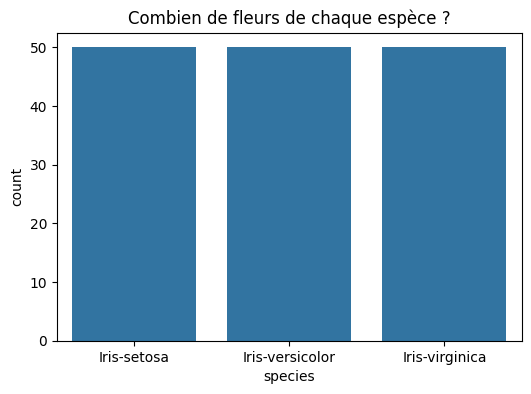

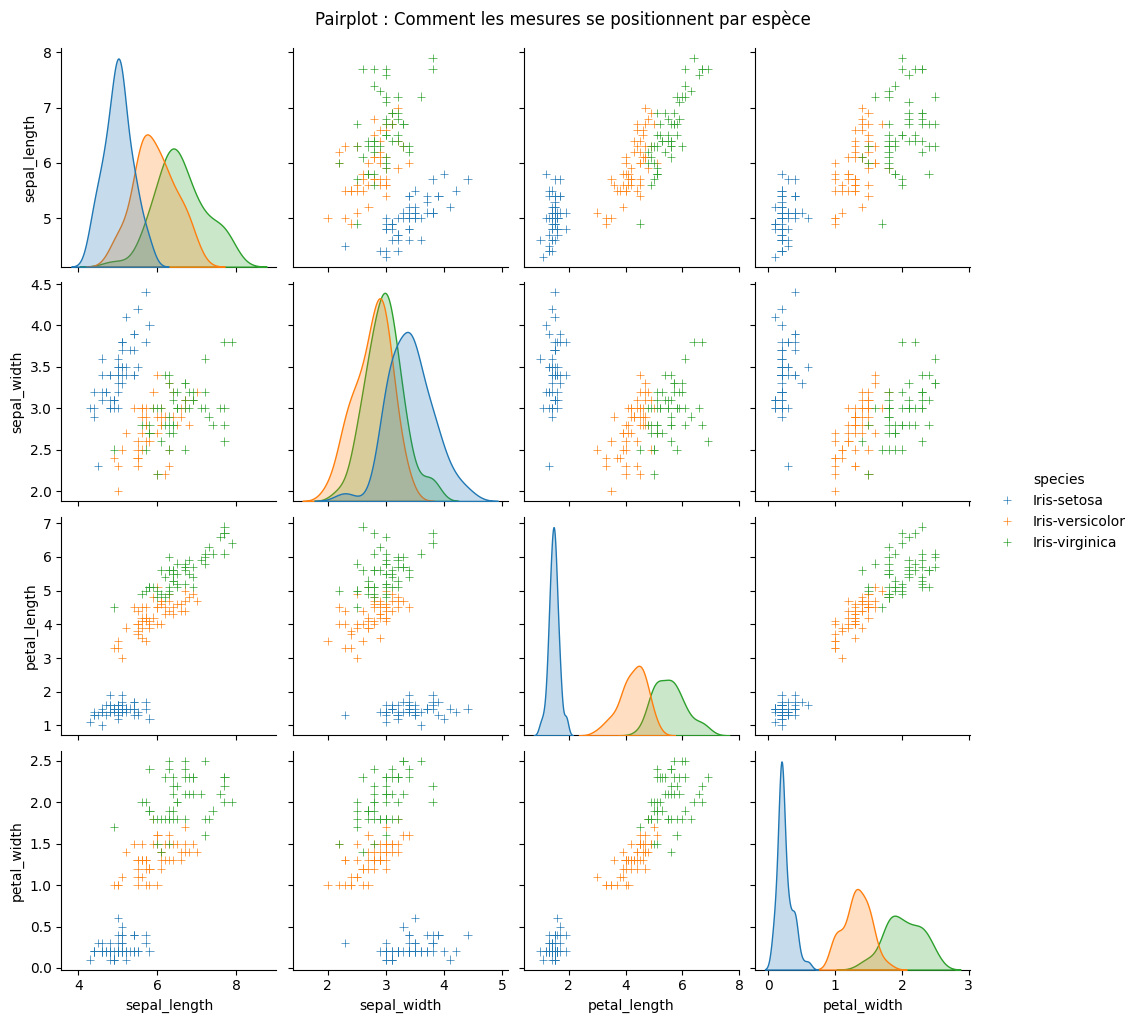

In [5]:
# Voir comment se répartissent les 3 espèces de fleurs
plt.figure(figsize=(6, 4))
sns.countplot(x='species', data=df)
plt.title('Combien de fleurs de chaque espèce ?')
plt.show()

# Voir la relation entre toutes les paires de mesures
sns.pairplot(df, hue='species', markers='+')
plt.suptitle("Pairplot : Comment les mesures se positionnent par espèce", y=1.02)
plt.show()

In [6]:
# 1. On sépare les caractéristiques (X) de la cible (y)
X = df.drop('species', axis=1)
y = df['species']

print("X (les mesures) :")
print(X.head(2))
print("\ny (l'espèce) :")
print(y.head(2))

# 2. On divise : 80% pour l'apprentissage, 20% pour le test final
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTaille de l'ensemble d'entraînement: {X_train.shape[0]} échantillons")
print(f"Taille de l'ensemble de test: {X_test.shape[0]} échantillons")

# 3. On normalise les données (moyenne 0, écart-type 1)
scaler = StandardScaler()
# On calcule la moyenne/écart-type SUR l'ensemble d'entraînement
scaler.fit(X_train)

# On applique la transformation sur les deux ensembles
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\n✅ Données normalisées !")

X (les mesures) :
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2

y (l'espèce) :
0    Iris-setosa
1    Iris-setosa
Name: species, dtype: object

Taille de l'ensemble d'entraînement: 120 échantillons
Taille de l'ensemble de test: 30 échantillons

✅ Données normalisées !


In [8]:
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test):
    """Entraîne un modèle et affiche ses performances de test."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"=== {model_name} === Accuracy = {acc:.4f}")

    # On stocke l'accuracy pour le comparatif de la fin
    return model_name, acc

In [9]:
results = [] # Liste pour stocker les résultats
model = LogisticRegression(max_iter=200)
nom, acc = evaluate_model(model, "Logistic Regression", X_train_scaled, X_test_scaled, y_train, y_test)
results.append((nom, acc))

=== Logistic Regression === Accuracy = 1.0000


In [10]:
model = DecisionTreeClassifier(max_depth=3, random_state=42) # max_depth évite le sur-apprentissage
nom, acc = evaluate_model(model, "Decision Tree", X_train_scaled, X_test_scaled, y_train, y_test)
results.append((nom, acc))

=== Decision Tree === Accuracy = 1.0000


In [11]:
model = KNeighborsClassifier(n_neighbors=5)
nom, acc = evaluate_model(model, "KNN (k=5)", X_train_scaled, X_test_scaled, y_train, y_test)
results.append((nom, acc))

=== KNN (k=5) === Accuracy = 1.0000


In [12]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
nom, acc = evaluate_model(model, "Random Forest", X_train_scaled, X_test_scaled, y_train, y_test)
results.append((nom, acc))

=== Random Forest === Accuracy = 1.0000


In [13]:
model = AdaBoostClassifier(n_estimators=100, random_state=42)
nom, acc = evaluate_model(model, "AdaBoost", X_train_scaled, X_test_scaled, y_train, y_test)
results.append((nom, acc))

=== AdaBoost === Accuracy = 0.9333


In [14]:
# Transformer les résultats en DataFrame pour un joli tableau
results_df = pd.DataFrame(results, columns=['Modèle', 'Accuracy Test'])
results_df = results_df.sort_values('Accuracy Test', ascending=False)
print("=== COMPARATIF FINAL ===")
print(results_df.to_string(index=False))

# Trouver le meilleur
best_model = results_df.iloc[0]
print(f"\n Le modèle le plus performant est {best_model['Modèle']} avec une accuracy de {best_model['Accuracy Test']:.2%}")

=== COMPARATIF FINAL ===
             Modèle  Accuracy Test
Logistic Regression       1.000000
      Decision Tree       1.000000
          KNN (k=5)       1.000000
      Random Forest       1.000000
           AdaBoost       0.933333

 Le modèle le plus performant est Logistic Regression avec une accuracy de 100.00%
